# Mapping MeSH descriptors to AOP Key Events (KEs)

#### Goal

Map MeSH descriptors to KEs from the AOP-Wiki database using Natural Language Processing, semantic search and indexing to identify correspondences between MeSH descriptors and AOP Key Events.

#### AOP Key Events 

- Extracted from AOP-Wiki  
- Includes KEs with detailed textual descriptions capturing biological processes, molecular events, or cellular responses  
- Some KEs only contain titles, as no public descriptions are available  

#### Environment set up

The following libraries are required for data manipulation, NLP tasks, data visualisation, evaluation metrics, and querying external resources.

In [1]:
# ==============================
# Data handling
# ==============================
import pandas as pd
import numpy as np
from collections import defaultdict


# ==============================
# NLP and semantic similarity
# ==============================
from sentence_transformers import SentenceTransformer, util
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification
from rapidfuzz import fuzz, process

# ==============================
# NLP preprocessing
# ==============================
import nltk
import scispacy
import spacy

# ==============================
# Machine Learning / evaluation
# ==============================
from sklearn import metrics
import torch

# ==============================
# Visualization
# ==============================
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# External data access
# ==============================
from SPARQLWrapper import SPARQLWrapper, JSON

## 1. Retrieve Key Events from the AOP-wiki SPARQL endpoint

This section connects to the AOP-wiki SPARQL endpoint to retrieve information about Key Events in AOPs.  
The workflow includes 3 main steps:   
- **Count total Key Events**: execute a SPARQL query to count all Key Events available on the AOP-wiki endpoint.  
- **Retrieve Key Events with descriptions**: queries for Key Events that have a publicly available description, along with their title, description and the AOP they belong to, then builds a Pandas Dataframe to store them.  
- **Retrieve Key Events without descriptions**: queries for Key Events that do **not** have a description and store them in a Pandas Dataframe.  

In [4]:
# Define the endpoint
endpoint_url = "https://aopwiki.rdf.bigcat-bioinformatics.org/sparql/"

In [8]:
# Count total available KEs
query = """
SELECT (COUNT(DISTINCT ?ke) AS ?totalKE)
WHERE {
    ?ke a aopo:KeyEvent .
}
"""
# Initialise the SPARQL wrapper and execute the query
sparql = SPARQLWrapper(endpoint_url)
sparql.setQuery(query)
sparql.setReturnFormat(JSON)
results = sparql.query().convert()

for result in results["results"]["bindings"]:
    print(result["totalKE"]["value"] + " AOP Key Events are currently available on the AOP-wiki SPARQL endpoint.")

1571 AOP Key Events are currently available on the AOP-wiki SPARQL endpoint.


In [38]:
# Retrieve KEs from AOP-Wiki (with description)
query = """
SELECT ?ke ?ketitle ?description
WHERE {
    ?ke a aopo:KeyEvent .
    ?ke dc:title ?ketitle .
    ?ke dc:description ?description .
} 
"""
# Initialise the SPARQL wrapper and execute the query
sparql = SPARQLWrapper(endpoint_url)
sparql.setQuery(query)
sparql.setReturnFormat(JSON)
results = sparql.query().convert()

# Build the dataframe with columns : 
# KE_ID | KE_TITLE | KE_DESCRIPTION | AOP_ID | AOP_TITLE
data = []
for result in results["results"]["bindings"]:
    ke_id = result["ke"]["value"]
    ke_title = result["ketitle"]["value"]
    ke_description = result["description"]["value"]
    data.append({
        "KE_ID" : ke_id,
        "KE_TITLE" : ke_title,
        "KE_DESCRIPTION" : ke_description
    })
AOP_KEs_description = pd.DataFrame(data)

# Count KEs
unique_ke_ids = AOP_KEs_description["KE_ID"].unique()
print(f"{len(unique_ke_ids)} Key Events have publicly available descriptions.")

626 Key Events have publicly available descriptions.


In [39]:
# Retrieve KEs from AOP-Wiki (with description)
query = """
SELECT ?ke ?ketitle 
WHERE {
    ?ke a aopo:KeyEvent .
    ?ke dc:title ?ketitle .
    FILTER NOT EXISTS { ?ke dc:description ?d . }
} 
"""
# Initialise the SPARQL wrapper and execute the query
sparql = SPARQLWrapper(endpoint_url)
sparql.setQuery(query)
sparql.setReturnFormat(JSON)
results = sparql.query().convert()

# Build the dataframe with columns : 
# KE_ID | KE_TITLE | AOP_ID | AOP_TITLE
data = []
for result in results["results"]["bindings"]:
    ke_id = result["ke"]["value"]
    ke_title = result["ketitle"]["value"]
    data.append({
        "KE_ID" : ke_id,
        "KE_TITLE" : ke_title
    })
AOP_KEs_no_description = pd.DataFrame(data)

# Count KEs
unique_ke_ids = AOP_KEs_no_description["KE_ID"].unique()
print(f"{len(unique_ke_ids)} Key Events do not have a publicly available description.")

945 Key Events do not have a publicly available description.


In [40]:
# Retrieve AOPs containing KEs
query = """
SELECT ?ke ?aop ?aoptitle
WHERE {
    ?ke a aopo:KeyEvent .
    ?ke dcterms:isPartOf ?aop .
    ?aop dc:title ?aoptitle
} 
"""
# Initialise the SPARQL wrapper and execute the query
sparql = SPARQLWrapper(endpoint_url)
sparql.setQuery(query)
sparql.setReturnFormat(JSON)
results = sparql.query().convert()

# Build the dataframe with columns : 
# KE_ID | KE_TITLE | AOP_ID | AOP_TITLE
data = []
for result in results["results"]["bindings"]:
    ke_id = result["ke"]["value"]
    ke_aop = result["aop"]["value"]
    aop_title = result["aoptitle"]["value"]
    data.append({
        "KE_ID" : ke_id,
        "AOP_ID" : ke_aop,
        "AOP_TITLE" : aop_title
    })
KE_to_AOP = pd.DataFrame(data)

Before performing further analyses, we convert the retrieved Key Events data (titles and descriptions) into lists for easier manipulation, filtering, and iteration in subsequent steps. We also check the length distributions of the title and description Strings.

In [41]:
# Prepare lists
ke_titles_description = AOP_KEs_description["KE_TITLE"].unique().tolist()
ke_titles_no_description = AOP_KEs_no_description["KE_TITLE"].unique().tolist()
ke_descriptions = AOP_KEs_description["KE_DESCRIPTION"].unique().tolist()

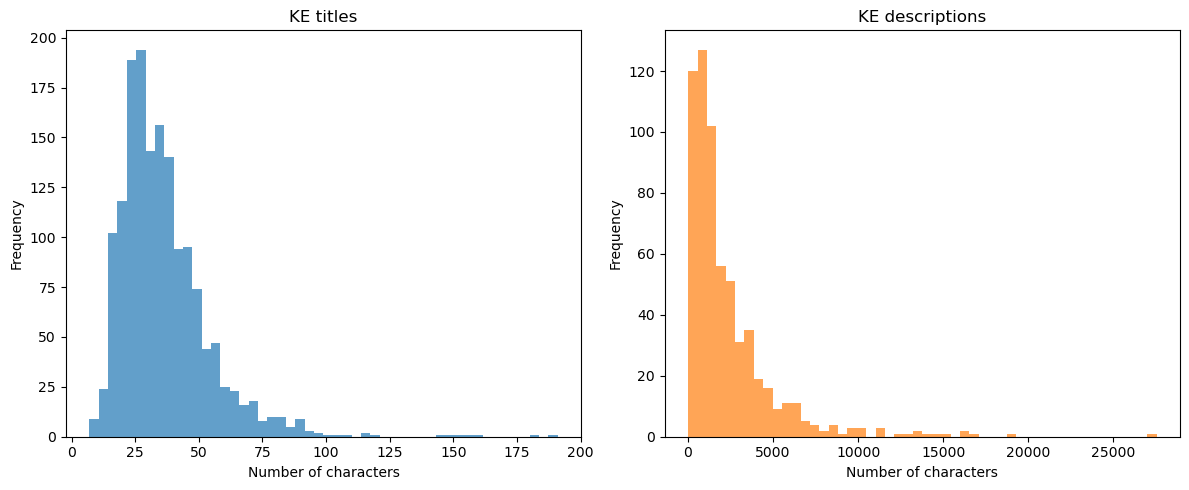

In [42]:
# Compute string lengths
ke_titles_lengths = [len(x) for x in ke_titles_description + ke_titles_no_description]
ke_descriptions_lengths = [len(x) for x in ke_descriptions]

# plot distributions of KE titles and KE descriptions lengths

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(ke_titles_lengths, bins=50, alpha=0.7, color="C0")
axes[0].set_title("KE titles")
axes[0].set_ylabel("Frequency")
axes[0].set_xlabel("Number of characters")
axes[1].hist(ke_descriptions_lengths, bins=50, alpha=0.7, color="C1")
axes[1].set_title("KE descriptions")
axes[1].set_ylabel("Frequency")
axes[1].set_xlabel("Number of characters")
plt.tight_layout()
plt.show()

## 2. Indexing on Key Events with publicly available descriptions

In this section, we build an indexer to retrieve relevant standardised MeSH (Medical Subject Headings) descriptors based on Key Events. This is applied only to Key Events that have a publicly available description, since the indexing relies on textual content.  
We use the [Wellcome/WellcomeBertMesh](https://huggingface.co/Wellcome/WellcomeBertMesh) model as the underlying annotator. This model is based on [BiomedBERT](https://huggingface.co/microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract) and was originally trained in the BioASQ competition to annotate biomedical texts with MeSH descriptors. While it was designed for research grants, it generalises well to any biomedical text, including AOP Key Event descriptions.

- **Input**: a Dataframe containing Key Events descriptions. For each Key Event, we use the description as input.  
- **Process**:
    - Each Key Event description is tokenised using the WellcomeBertMesh tokenizer, with padding and truncation to a fixed length.  
    - The tonekised text is fed into the WellcomeBertMesh, and predictions are generated.  
    - The model outputs predicted MeSH descriptors for the Key Event description.  
- **Output**: a list of dictionaires where each entry contains the Key Event ID and a list of predicted MeSH descriptors associated with that Key Event.

In [43]:
wellcomeBertMesh_tokenizer = AutoTokenizer.from_pretrained("Wellcome/WellcomeBertMesh")
wellcomeBertMesh_model = AutoModel.from_pretrained("Wellcome/WellcomeBertMesh", trust_remote_code = True)

Some weights of the model checkpoint at microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract were not used when initializing BertModel: ['cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.seq_relationship.weight', 'cls.predictions.decoder.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.decoder.weight', 'cls.predictions.bias', 'cls.seq_relationship.bias']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [44]:
indexing_results = []

wellcomeBertMesh_model.eval()

with torch.no_grad():
    for _, row in AOP_KEs_description.iterrows():
        id = row["KE_ID"]
        description = row["KE_DESCRIPTION"]

        inputs = wellcomeBertMesh_tokenizer(
            [description],
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        labels = wellcomeBertMesh_model(**inputs, return_labels=True)

        indexing_results.append({
            "KE_ID": id,
            "MESH_TITLES": labels[0]
        })

In [ ]:
# flatten the list
indexing_results_flatten = []
for entry in indexing_results :
    ke_id = entry["KE_ID"]
    for mesh in entry["MESH_TITLES"] :
        indexing_results_flatten.append({'KE_ID' : ke_id, 'MESH_TITLE' : mesh})

indexing_results_dataframe = pd.DataFrame(indexing_results_flatten)

In [36]:
print(indexing_results_flatten)

[{'ke_title': 'https://identifiers.org/aop.events/2252', 'mesh_title': 'Celiac Disease'}, {'ke_title': 'https://identifiers.org/aop.events/2252', 'mesh_title': 'Diet, Gluten-Free'}, {'ke_title': 'https://identifiers.org/aop.events/2252', 'mesh_title': 'GTP-Binding Proteins'}, {'ke_title': 'https://identifiers.org/aop.events/2252', 'mesh_title': 'Glutens'}, {'ke_title': 'https://identifiers.org/aop.events/2252', 'mesh_title': 'HLA-DQ Antigens'}, {'ke_title': 'https://identifiers.org/aop.events/2252', 'mesh_title': 'Humans'}, {'ke_title': 'https://identifiers.org/aop.events/2252', 'mesh_title': 'Peptides'}, {'ke_title': 'https://identifiers.org/aop.events/2252', 'mesh_title': 'Transglutaminases'}, {'ke_title': 'https://identifiers.org/aop.events/2253', 'mesh_title': 'Celiac Disease'}, {'ke_title': 'https://identifiers.org/aop.events/2253', 'mesh_title': 'Epitopes'}, {'ke_title': 'https://identifiers.org/aop.events/2253', 'mesh_title': 'Epitopes, T-Lymphocyte'}, {'ke_title': 'https://iden